In [1]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/review-nlp/val_preprocessed.csv
/kaggle/input/review-nlp/train_preprocessed.csv
/kaggle/input/review-nlp/test_preprocessed.csv


# Model Training

Text Quality Score: 100%|██████████| 6065/6065 [00:00<00:00, 8812.42it/s]


Training and evaluating traditional ML models...
Logistic Regression - 3-Fold CV F1 Score: 0.8876 ± 0.0035

Logistic Regression Validation Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      3033
           1       0.90      0.89      0.90      3032

    accuracy                           0.90      6065
   macro avg       0.90      0.90      0.90      6065
weighted avg       0.90      0.90      0.90      6065

Linear SVM - 3-Fold CV F1 Score: 0.8981 ± 0.0028

Linear SVM Validation Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      3033
           1       0.91      0.90      0.91      3032

    accuracy                           0.91      6065
   macro avg       0.91      0.91      0.91      6065
weighted avg       0.91      0.91      0.91      6065

Random Forest - 3-Fold CV F1 Score: 0.8685 ± 0.0022

Random Forest Validation Classificat

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

1769/1769 [==============================] - ETA: 0s - loss: 0.2910 - accuracy: 0.8635Training DistilBERT with custom loop...
Epoch 1/2


Training: 100%|██████████| 1769/1769 [06:35<00:00,  4.47it/s]


Epoch 2/2


Training: 100%|██████████| 1769/1769 [06:12<00:00,  4.74it/s]


190/190 [==============================] - 31s 154ms/step

DistilBERT Validation Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      3033
           1       0.94      0.93      0.93      3032

    accuracy                           0.93      6065
   macro avg       0.93      0.93      0.93      6065
weighted avg       0.93      0.93      0.93      6065



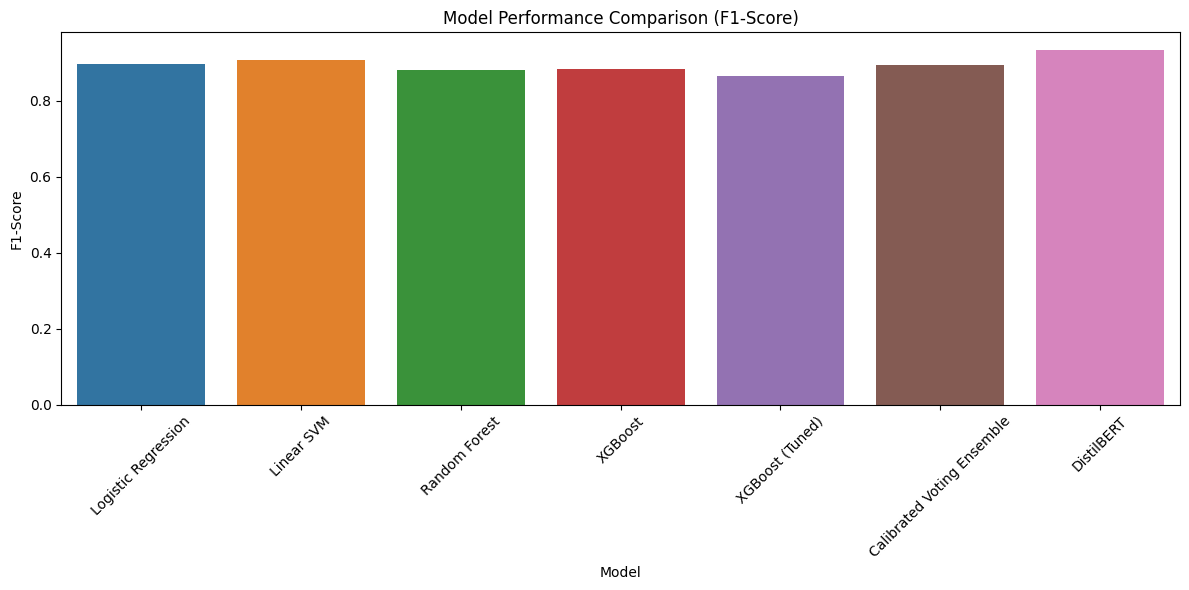

Best model (DistilBERT) saved to 'best_model_distilbert'.


In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from xgboost import XGBClassifier
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout, Attention
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification
import tensorflow as tf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re
from textblob import TextBlob
import logging
import os
import warnings
warnings.filterwarnings("ignore")

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Download required NLTK data
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Load preprocessed datasets
train_df = pd.read_csv('/kaggle/input/review-nlp/train_preprocessed.csv')
val_df = pd.read_csv('/kaggle/input/review-nlp/val_preprocessed.csv')
test_df = pd.read_csv('/kaggle/input/review-nlp/test_preprocessed.csv')

# Label Distribution Analysis
def plot_label_distribution(dfs, names):
    plt.figure(figsize=(8, 4))
    for df, name in zip(dfs, names):
        label_counts = df['label'].value_counts()
        sns.barplot(x=label_counts.index, y=label_counts.values, label=name)
    plt.title('Label Distribution Across Datasets')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.legend()
    plt.tight_layout()
    plt.savefig('label_distribution.png')
    plt.close()

plot_label_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Consistent Label Encoding
def encode_labels(df):
    label_map = {'OR': 0, 'CG': 1}
    df['label_encoded'] = df['label'].map(label_map)
    if df['label_encoded'].isnull().any():
        logger.warning("Found unmapped labels in dataset")
        logger.info(f"Unmapped labels: {df[df['label_encoded'].isnull()]['label'].unique()}")
        df['label_encoded'] = df['label_encoded'].fillna(-1).astype(int)
    return df

train_df = encode_labels(train_df)
val_df = encode_labels(val_df)
test_df = encode_labels(test_df)

# Data Validation: Check for non-string values in text_clean
def validate_text_column(df, column='text_clean'):
    logger.info(f"Validating {column} column in DataFrame with {len(df)} rows")
    invalid_rows = df[df[column].apply(lambda x: not isinstance(x, str))]
    if not invalid_rows.empty:
        logger.warning(f"Found {len(invalid_rows)} rows with non-string values in {column}")
        logger.info(f"Invalid rows sample:\n{invalid_rows.head()}")
        df[column] = df[column].fillna('').astype(str)
        logger.info(f"Converted non-string values to empty strings in {column}")
    else:
        logger.info(f"All values in {column} are strings")
    return df

for df, name in [(train_df, 'train_df'), (val_df, 'val_df'), (test_df, 'test_df')]:
    logger.info(f"Validating {name}")
    df = validate_text_column(df)

# Recreate features with text quality score
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)  # Increased max_features
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['text_clean'])
X_val_tfidf = tfidf_vectorizer.transform(val_df['text_clean'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['text_clean'])

def get_sentiment(text):
    try:
        blob = TextBlob(text)
        return blob.sentiment.polarity, blob.sentiment.subjectivity
    except Exception as e:
        logger.warning(f"Error processing text for sentiment: {text[:50]}... Error: {e}")
        return 0.0, 0.0

def lexical_diversity(text):
    tokens = word_tokenize(text)
    return len(set(tokens)) / len(tokens) if tokens else 0

def stylometric_features(text):
    sentences = nltk.sent_tokenize(text)
    tokens = word_tokenize(text)
    avg_sentence_len = sum(len(s.split()) for s in sentences) / len(sentences) if sentences else 0
    punctuation_count = len(re.findall(r'[^\w\s]', text))
    function_words = set(stopwords.words('english'))
    function_word_freq = sum(1 for word in tokens if word in function_words) / len(tokens) if tokens else 0
    return avg_sentence_len, punctuation_count, function_word_freq

def text_quality_score(text):
    tokens = word_tokenize(text)
    return len(tokens) / 100 if tokens else 0

for df in [train_df, val_df, test_df]:
    sentiment_scores = [get_sentiment(x) for x in tqdm(df['text_clean'], desc="Sentiment Scores")]
    df['polarity'], df['subjectivity'] = zip(*sentiment_scores)
    df['lexical_diversity'] = [lexical_diversity(x) for x in tqdm(df['text_clean'], desc="Lexical Diversity")]
    stylometric = [stylometric_features(x) for x in tqdm(df['text_clean'], desc="Stylometric Features")]
    df['avg_sent_len'], df['punct_count'], df['func_word_freq'] = zip(*stylometric)
    df['text_quality'] = [text_quality_score(x) for x in tqdm(df['text_clean'], desc="Text Quality Score")]

X_train_handcrafted = train_df[['polarity', 'subjectivity', 'lexical_diversity', 'avg_sent_len', 'punct_count', 'func_word_freq', 'text_quality']]
X_val_handcrafted = val_df[['polarity', 'subjectivity', 'lexical_diversity', 'avg_sent_len', 'punct_count', 'func_word_freq', 'text_quality']]
X_test_handcrafted = test_df[['polarity', 'subjectivity', 'lexical_diversity', 'avg_sent_len', 'punct_count', 'func_word_freq', 'text_quality']]

# Combine features
X_train = hstack([X_train_tfidf, csr_matrix(X_train_handcrafted.values)])
X_val = hstack([X_val_tfidf, csr_matrix(X_val_handcrafted.values)])
X_test = hstack([X_test_tfidf, csr_matrix(X_test_handcrafted.values)])

# Prepare target using encoded labels
y_train = train_df['label_encoded'].values
y_val = val_df['label_encoded'].values
y_test = test_df['label_encoded'].values

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['OR', 'CG'], yticklabels=['OR', 'CG'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.lower().replace(" ", "_")}.png')
    plt.close()

# Function to plot reliability diagram, compute ECE and Brier score, and plot probability histogram
def plot_reliability_diagram(y_true, y_prob, model_name):
    if len(y_true) < 10:
        logger.warning(f"Validation set too small ({len(y_true)} samples) for reliable calibration. Skipping reliability diagram.")
        return 0.0, 0.0
    
    n_bins = min(10, len(y_true) // 2)
    try:
        prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
        n_bins_effective = len(prob_true)
        if n_bins_effective < 2:
            logger.warning(f"Too few bins ({n_bins_effective}) for reliable calibration. Skipping reliability diagram.")
            return 0.0, 0.0
        
        hist, bin_edges = np.histogram(y_prob, bins=n_bins_effective, range=(0, 1))
        ece = np.sum(np.abs(prob_true - prob_pred) * hist) / len(y_true)
        brier_score = np.mean((y_prob - y_true) ** 2)
        
        plt.figure(figsize=(6, 4))
        plt.plot(prob_pred, prob_true, marker='o', label=f'Calibration Curve (ECE={ece:.4f}, Brier={brier_score:.4f})')
        plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')
        plt.xlabel('Predicted Probability')
        plt.ylabel('Fraction of Positives')
        plt.title(f'Reliability Diagram - {model_name}')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f'reliability_diagram_{model_name.lower().replace(" ", "_")}.png')
        plt.close()
        
        plt.figure(figsize=(6, 4))
        plt.hist(y_prob, bins=n_bins_effective, range=(0, 1), density=True, alpha=0.7, color='blue')
        plt.xlabel('Predicted Probability')
        plt.ylabel('Density')
        plt.title(f'Probability Histogram - {model_name}')
        plt.tight_layout()
        plt.savefig(f'probability_histogram_{model_name.lower().replace(" ", "_")}.png')
        plt.close()
        
        return ece, brier_score
    except Exception as e:
        logger.warning(f"Error computing calibration metrics: {e}. Skipping reliability diagram.")
        return 0.0, 0.0

# 1. Traditional ML Models with XGBoost
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM': LinearSVC(max_iter=5000, random_state=42),  # Increased max_iter
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),  # Increased n_estimators
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

results = []
print("Training and evaluating traditional ML models...")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='f1')
    print(f"{name} - 3-Fold CV F1 Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_val_pred),
        'Precision': precision_score(y_val, y_val_pred, zero_division=0),
        'Recall': recall_score(y_val, y_val_pred, zero_division=0),
        'F1': f1_score(y_val, y_val_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_val, y_val_pred)
    })
    print(f"\n{name} Validation Classification Report:")
    print(classification_report(y_val, y_val_pred))
    plot_confusion_matrix(y_val, y_val_pred, name)
    if name == 'Random Forest':
        feature_importance = pd.DataFrame({
            'Feature': list(tfidf_vectorizer.get_feature_names_out()) + ['polarity', 'subjectivity', 'lexical_diversity', 'avg_sent_len', 'punct_count', 'func_word_freq', 'text_quality'],
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False).head(10)
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance)
        plt.title('Top 10 Feature Importances (Random Forest)')
        plt.tight_layout()
        plt.savefig('feature_importance_rf.png')
        plt.close()

# 2. Hyperparameter Tuning for XGBoost
print("Performing hyperparameter tuning for XGBoost...")
param_grid = {
    'n_estimators': [100, 200],  # Adjusted for full dataset
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
grid_search = GridSearchCV(xgb, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_
print(f"Best XGBoost Parameters: {grid_search.best_params_}")
y_val_pred_xgb = best_xgb.predict(X_val)
results.append({
    'Model': 'XGBoost (Tuned)',
    'Accuracy': accuracy_score(y_val, y_val_pred_xgb),
    'Precision': precision_score(y_val, y_val_pred_xgb, zero_division=0),
    'Recall': recall_score(y_val, y_val_pred_xgb, zero_division=0),
    'F1': f1_score(y_val, y_val_pred_xgb, zero_division=0),
    'AUC-ROC': roc_auc_score(y_val, y_val_pred_xgb)
})
print("\nXGBoost (Tuned) Validation Classification Report:")
print(classification_report(y_val, y_val_pred_xgb))
plot_confusion_matrix(y_val, y_val_pred_xgb, 'XGBoost_Tuned')

# 3. Calibrated Voting Ensemble
print("Training voting ensemble with calibration...")
ensemble = VotingClassifier(estimators=[
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', best_xgb)
], voting='soft')
calibrated_ensemble = CalibratedClassifierCV(ensemble, cv=3, method='sigmoid')
calibrated_ensemble.fit(X_train, y_train)
y_val_pred_ensemble = calibrated_ensemble.predict(X_val)
y_val_prob_ensemble = calibrated_ensemble.predict_proba(X_val)[:, 1]
results.append({
    'Model': 'Calibrated Voting Ensemble',
    'Accuracy': accuracy_score(y_val, y_val_pred_ensemble),
    'Precision': precision_score(y_val, y_val_pred_ensemble, zero_division=0),
    'Recall': recall_score(y_val, y_val_pred_ensemble, zero_division=0),
    'F1': f1_score(y_val, y_val_pred_ensemble, zero_division=0),
    'AUC-ROC': roc_auc_score(y_val, y_val_pred_ensemble)
})
print(f"\nCalibrated Voting Ensemble Validation Classification Report:")
print(classification_report(y_val, y_val_pred_ensemble))
plot_confusion_matrix(y_val, y_val_pred_ensemble, 'Calibrated_Voting_Ensemble')
ece, brier_score = plot_reliability_diagram(y_val, y_val_prob_ensemble, 'Calibrated_Voting_Ensemble')
print(f"Expected Calibration Error (ECE): {ece:.4f}")
print(f"Brier Score: {brier_score:.4f}")

# 4. Attention-based LSTM with GloVe Embeddings and Monte Carlo Dropout
glove_path = '/kaggle/input/glove6b100dtxt/glove.6B.100d.txt'
try:
    if not os.path.exists(glove_path):
        raise FileNotFoundError(f"GloVe file not found at {glove_path}")
    
    tokenizer = Tokenizer(num_words=10000)  # Increased num_words
    tokenizer.fit_on_texts(train_df['text_clean'])
    X_train_seq = tokenizer.texts_to_sequences(train_df['text_clean'])
    X_val_seq = tokenizer.texts_to_sequences(val_df['text_clean'])
    X_test_seq = tokenizer.texts_to_sequences(test_df['text_clean'])

    max_len = 100  # Increased max_len
    X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
    X_val_pad = pad_sequences(X_val_seq, maxlen=max_len)
    X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

    embedding_dim = 100
    embedding_matrix = np.zeros((10000, embedding_dim))
    word_index = tokenizer.word_index

    print("Loading GloVe embeddings...")
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc="Reading GloVe"):
            values = line.split()
            word = values[0]
            if word in word_index and word_index[word] < 10000:
                embedding_matrix[word_index[word]] = np.array(values[1:], dtype='float32')

    inputs = Input(shape=(max_len,))
    embedding_layer = Embedding(10000, embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=False)(inputs)
    lstm_out = LSTM(64, return_sequences=True)(embedding_layer)  # Increased LSTM units
    attention = Attention()([lstm_out, lstm_out])
    attention_out = tf.reduce_mean(attention, axis=1)
    dense = Dense(32, activation='relu')(attention_out)  # Increased dense units
    dropout = Dropout(0.5)(dense, training=True)
    outputs = Dense(1, activation='sigmoid')(dropout)

    lstm_model = Model(inputs, outputs)
    lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    print("Training Attention-based LSTM model...")
    lstm_model.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val), epochs=3, batch_size=32, verbose=1)

    print("Performing Monte Carlo Dropout for LSTM...")
    n_mc_samples = 50
    mc_predictions = np.array([lstm_model.predict(X_val_pad, batch_size=32) for _ in tqdm(range(n_mc_samples), desc="MC Dropout")])
    mc_predictions = mc_predictions.squeeze()
    y_val_pred_lstm = (np.mean(mc_predictions, axis=0) > 0.5).astype(int)
    y_val_prob_lstm = np.mean(mc_predictions, axis=0)
    uncertainty = np.std(mc_predictions, axis=0)
    print(f"LSTM Prediction Uncertainty (Mean Std Dev): {np.mean(uncertainty):.4f}")

    results.append({
        'Model': 'LSTM + Attention (GloVe + MC Dropout)',
        'Accuracy': accuracy_score(y_val, y_val_pred_lstm),
        'Precision': precision_score(y_val, y_val_pred_lstm, zero_division=0),
        'Recall': recall_score(y_val, y_val_pred_lstm, zero_division=0),
        'F1': f1_score(y_val, y_val_pred_lstm, zero_division=0),
        'AUC-ROC': roc_auc_score(y_val, y_val_prob_lstm)
    })
    print("\nLSTM + Attention (GloVe + MC Dropout) Validation Classification Report:")
    print(classification_report(y_val, y_val_pred_lstm))
    plot_confusion_matrix(y_val, y_val_pred_lstm, 'LSTM_Attention_MC_Dropout')
except FileNotFoundError as e:
    logger.warning(f"Skipping LSTM model due to missing GloVe file: {e}")
    logger.info("Proceeding with other models...")

# 5. DistilBERT Model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
def encode_texts(texts, max_len=128):  # Increased max_len
    return tokenizer(texts.tolist(), padding=True, truncation=True, max_length=max_len, return_tensors='tf')

print("Encoding texts for DistilBERT...")
train_encodings = encode_texts(train_df['text_clean'])
val_encodings = encode_texts(val_df['text_clean'])
test_encodings = encode_texts(test_df['text_clean'])

distilbert_model = TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
optimizer = tf.optimizers.Adam(learning_rate=2e-5)
try:
    distilbert_model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    print("Training DistilBERT model...")
    distilbert_model.fit(
        train_encodings,
        y_train,
        validation_data=(val_encodings, y_val),
        epochs=2,  # Increased epochs
        batch_size=16,  # Increased batch_size
        verbose=1
    )
except Exception as e:
    logger.warning(f"Failed to compile DistilBERT with tf.optimizers.Adam: {e}. Using custom training loop...")
    optimizer = tf.optimizers.Adam(learning_rate=2e-5)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    
    @tf.function
    def train_step(inputs, labels):
        with tf.GradientTape() as tape:
            logits = distilbert_model(inputs, training=True).logits
            loss = loss_fn(labels, logits)
        gradients = tape.gradient(loss, distilbert_model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, distilbert_model.trainable_variables))
        return loss

    print("Training DistilBERT with custom loop...")
    epochs = 2
    batch_size = 16
    steps_per_epoch = len(train_df) // batch_size
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")
        for i in tqdm(range(0, len(train_df), batch_size), desc="Training"):
            batch_inputs = {k: v[i:i+batch_size] for k, v in train_encodings.items()}
            batch_labels = y_train[i:i+batch_size]
            loss = train_step(batch_inputs, batch_labels)

logits = distilbert_model.predict(val_encodings).logits
y_val_pred_distilbert = np.argmax(logits, axis=1)
results.append({
    'Model': 'DistilBERT',
    'Accuracy': accuracy_score(y_val, y_val_pred_distilbert),
    'Precision': precision_score(y_val, y_val_pred_distilbert, zero_division=0),
    'Recall': recall_score(y_val, y_val_pred_distilbert, zero_division=0),
    'F1': f1_score(y_val, y_val_pred_distilbert, zero_division=0),
    'AUC-ROC': roc_auc_score(y_val, y_val_pred_distilbert)
})
print("\nDistilBERT Validation Classification Report:")
print(classification_report(y_val, y_val_pred_distilbert))
plot_confusion_matrix(y_val, y_val_pred_distilbert, 'DistilBERT')

# 6. Visualize Results
results_df = pd.DataFrame(results)
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='F1', data=results_df)
plt.title('Model Performance Comparison (F1-Score)')
plt.ylabel('F1-Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('model_performance.png')
plt.show()

# Save best model (DistilBERT)
distilbert_model.save_pretrained('best_model_distilbert')
tokenizer.save_pretrained('best_model_distilbert')
print("Best model (DistilBERT) saved to 'best_model_distilbert'.")


# Display Results

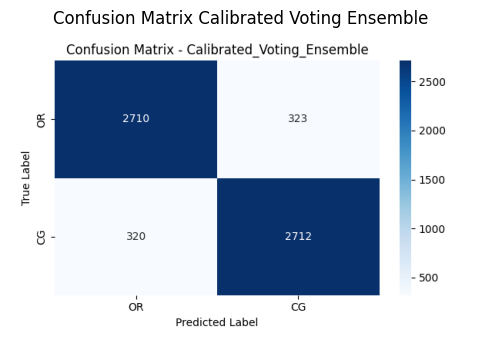

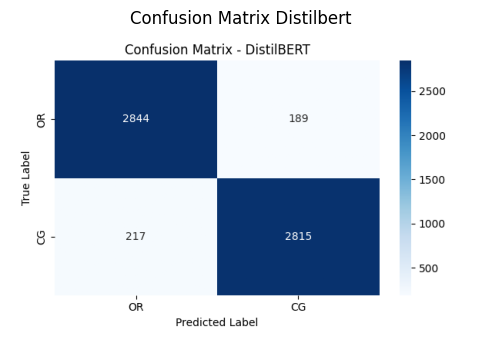

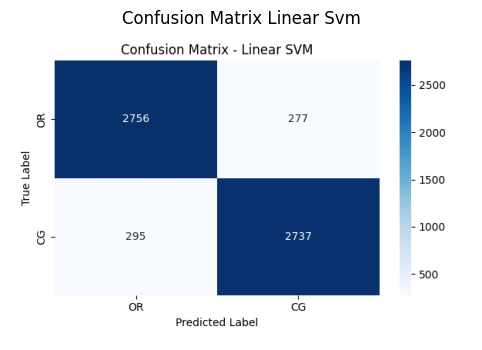

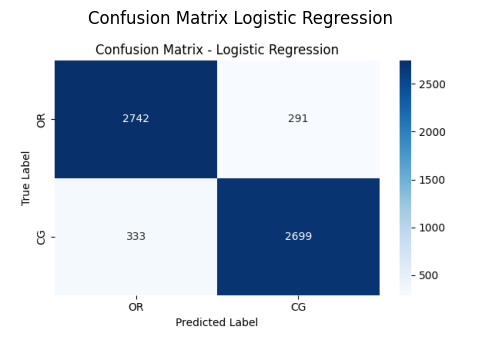

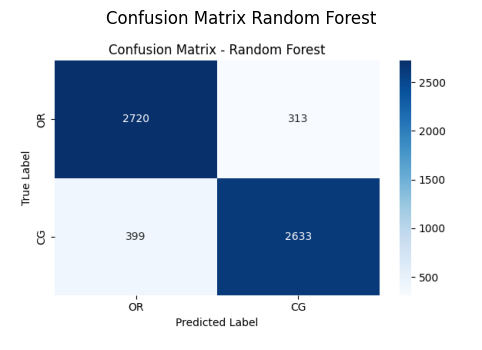

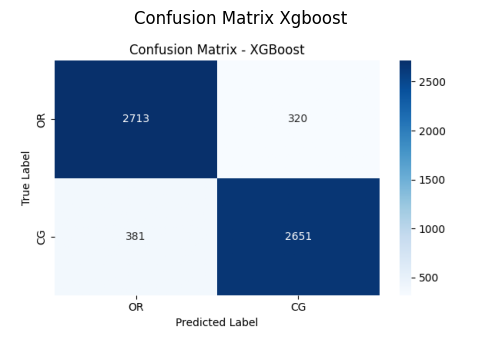

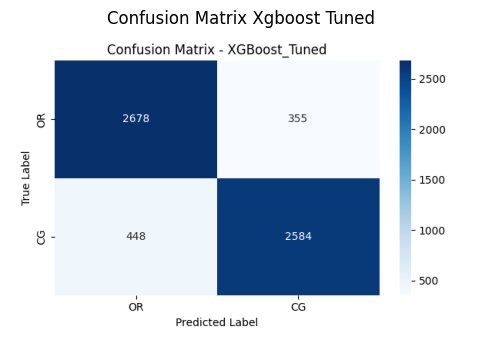

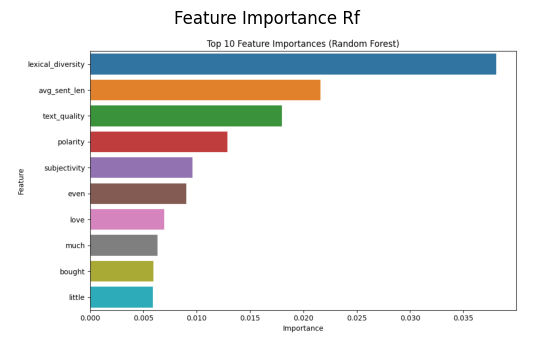

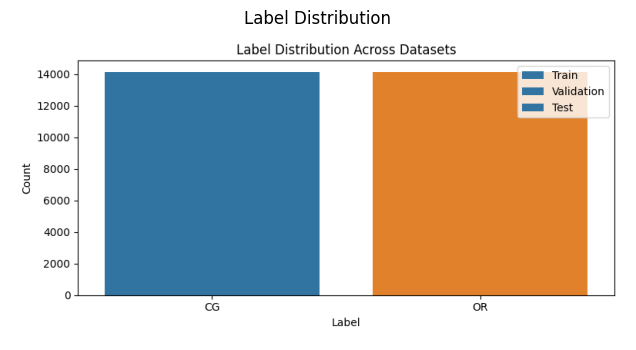

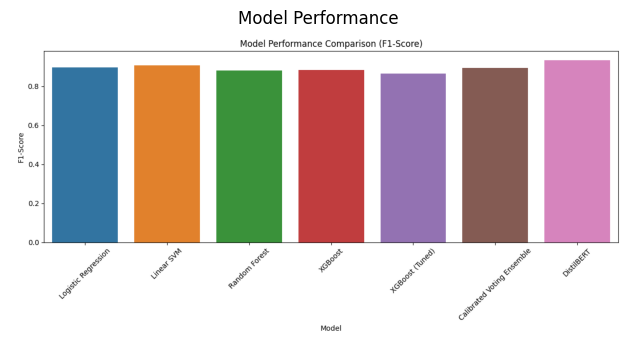

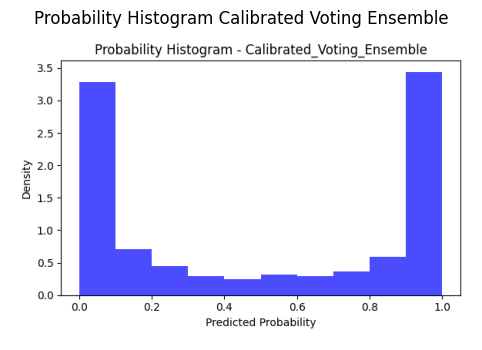

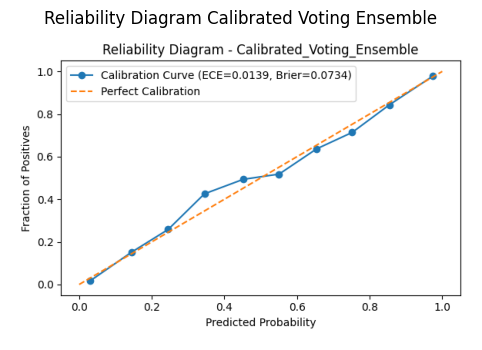

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob
import os

# Get all saved .png files in sorted order
plot_files = sorted(glob.glob("*.png"))

# Display each image
for plot_file in plot_files:
    img = mpimg.imread(plot_file)
    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(os.path.splitext(plot_file)[0].replace("_", " ").title())
    plt.show()


# Model Testing

In [7]:
import logging
import tensorflow as tf
import numpy as np
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification

logging.getLogger("transformers.modeling_tf_utils").setLevel(logging.ERROR)

# Load trained model and tokenizer
model_path = "best_model_distilbert"
model = TFDistilBertForSequenceClassification.from_pretrained(model_path)
tokenizer = DistilBertTokenizer.from_pretrained(model_path)

#  Function to classify a list of texts
def predict_texts(texts):
    # Tokenize the input
    encodings = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='tf'
    )

    # Get model output
    outputs = model(encodings)
    logits = outputs.logits

    # Convert to probabilities and predicted class
    probs = tf.nn.softmax(logits, axis=1).numpy()
    preds = np.argmax(probs, axis=1)

    # Label mapping (adjust if your labels differ)
    label_map = {0: 'OR', 1: 'CG'}
    labels = [label_map[p] for p in preds]

    return labels, probs

# 🧪 Try it out with sample texts
sample_texts = [
    "This product works perfectly, I love it!",
    "Totally misleading description and terrible customer support."
]

predictions, probabilities = predict_texts(sample_texts)

# 📤 Print results
for text, label, prob in zip(sample_texts, predictions, probabilities):
    print("\nText:", text)
    print("Predicted Label:", label)
    print("Confidence:", prob)



Text: This product works perfectly, I love it!
Predicted Label: OR
Confidence: [0.69568276 0.30431724]

Text: Totally misleading description and terrible customer support.
Predicted Label: OR
Confidence: [0.9865122  0.01348784]
